Calculated Slope (m): 0.9500
Calculated Intercept (c): 0.5900


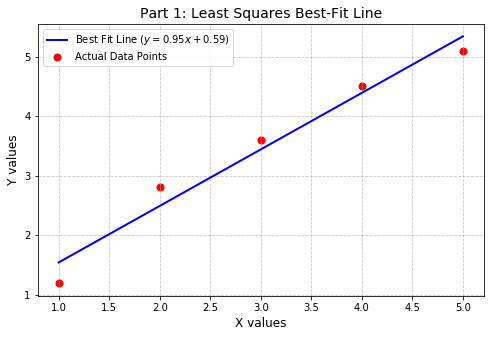

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the data points
X = np.array([1, 2, 3, 4, 5])
Y = np.array([1.2, 2.8, 3.6, 4.5, 5.1])

# 2. Stack the design matrix with a column of ones (for the intercept)
A = np.vstack([X, np.ones(len(X))]).T

# 3. Solve using least squares
m, c = np.linalg.lstsq(A, Y, rcond=None)[0]
print(f"Calculated Slope (m): {m:.4f}")
print(f"Calculated Intercept (c): {c:.4f}")

# 4. Plot the data points and the best-fit line
plt.figure(figsize=(8, 5))
plt.scatter(X, Y, color='red', s=50, label='Actual Data Points')

# Generate the predicted y-values for the line
Y_pred = m * X + c
plt.plot(X, Y_pred, color='blue', linewidth=2, label=f'Best Fit Line ($y = {m:.2f}x + {c:.2f}$)')

# Formatting the plot
plt.title('Part 1: Least Squares Best-Fit Line', fontsize=14)
plt.xlabel('X values', fontsize=12)
plt.ylabel('Y values', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Random Data - Slope: -0.3298
Random Data - Intercept: 6.6339


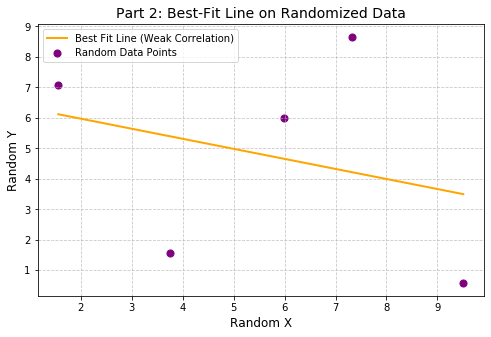

In [3]:
# 1. Generate random vectors (using random floats between 0 and 10)
np.random.seed(42) # Set seed for reproducibility
X_rand = np.random.uniform(0, 10, 5)
Y_rand = np.random.uniform(0, 10, 5)

# 2. Stack the design matrix
A_rand = np.vstack([X_rand, np.ones(len(X_rand))]).T

# 3. Solve using least squares
m_rand, c_rand = np.linalg.lstsq(A_rand, Y_rand, rcond=None)[0]
print(f"Random Data - Slope: {m_rand:.4f}")
print(f"Random Data - Intercept: {c_rand:.4f}")

# 4. Plot the randomized data and its best-fit line
plt.figure(figsize=(8, 5))
plt.scatter(X_rand, Y_rand, color='purple', s=50, label='Random Data Points')

# Create a smooth line range based on the min and max of our random X values
x_line = np.linspace(min(X_rand), max(X_rand), 100)
y_line = m_rand * x_line + c_rand

plt.plot(x_line, y_line, color='orange', linewidth=2, label='Best Fit Line (Weak Correlation)')

# Formatting the plot
plt.title('Part 2: Best-Fit Line on Randomized Data', fontsize=14)
plt.xlabel('Random X', fontsize=12)
plt.ylabel('Random Y', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

--- Parameter Recovery Comparison ---
Original Equation:  y = 3.5000x + 1.2500
Estimated Equation: y = 3.6525x + 1.1286
The Least Squares model successfully approximated the original parameters despite the noise.



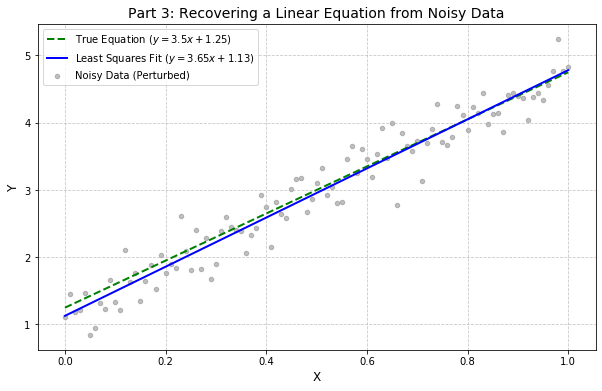

In [4]:
# 1. Define the true parameters of my own linear equation
true_m = 3.5
true_c = 1.25

# 2. Generate X values from 0 to 1 with steps of 0.01
X_custom = np.arange(0, 1.01, 0.01)

# 3. Compute Y using the linear equation +/- a random perturbation (Gaussian noise)
# Using a normal distribution centered at 0 with a standard deviation of 0.3 for noise
noise = np.random.normal(0, 0.3, len(X_custom))
Y_custom = (true_m * X_custom) + true_c + noise

# 4. Stack the design matrix
A_custom = np.vstack([X_custom, np.ones(len(X_custom))]).T

# 5. Compute the Least Squares
m_custom, c_custom = np.linalg.lstsq(A_custom, Y_custom, rcond=None)[0]

# Display the comparison
print("--- Parameter Recovery Comparison ---")
print(f"Original Equation:  y = {true_m:.4f}x + {true_c:.4f}")
print(f"Estimated Equation: y = {m_custom:.4f}x + {c_custom:.4f}")
print(f"The Least Squares model successfully approximated the original parameters despite the noise.\n")

# 6. Plot the noisy data, the true line, and the best-fit line
plt.figure(figsize=(10, 6))

# Plot the noisy raw data
plt.scatter(X_custom, Y_custom, color='gray', alpha=0.5, s=20, label='Noisy Data (Perturbed)')

# Plot the original "True" line
plt.plot(X_custom, true_m * X_custom + true_c, color='green', linestyle='--', linewidth=2, 
         label=f'True Equation ($y={true_m}x+{true_c}$)')

# Plot the computed Least Squares fit
plt.plot(X_custom, m_custom * X_custom + c_custom, color='blue', linewidth=2, 
         label=f'Least Squares Fit ($y={m_custom:.2f}x+{c_custom:.2f}$)')

# Formatting the plot
plt.title('Part 3: Recovering a Linear Equation from Noisy Data', fontsize=14)
plt.xlabel('X', fontsize=12)
plt.ylabel('Y', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()